## Insider Threat Radar – Behavior Analytics for Employee Risk Prediction

### Evaluation & Risk Scoring

#### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

#### Load Data & Models

In [2]:
data = pd.read_csv("../Dataset/anomaly_output.csv")

rf = joblib.load("../Model/random_forest.pkl")
gb = joblib.load("../Model/gradient_boosting.pkl")
mlp = joblib.load("../Model/mlp_model.pkl")

print("Data & models loaded ✅")

Data & models loaded ✅


#### Prepare X & y

In [3]:
feature_cols = [
    'total_emails','total_attachments','avg_email_size',
    'off_hour_emails','weekend_emails',
    'O','C','E','A','N'
]

X = data[feature_cols]
y = data['anomaly_flag']

### 🔍 Evaluation

#### Random Forest

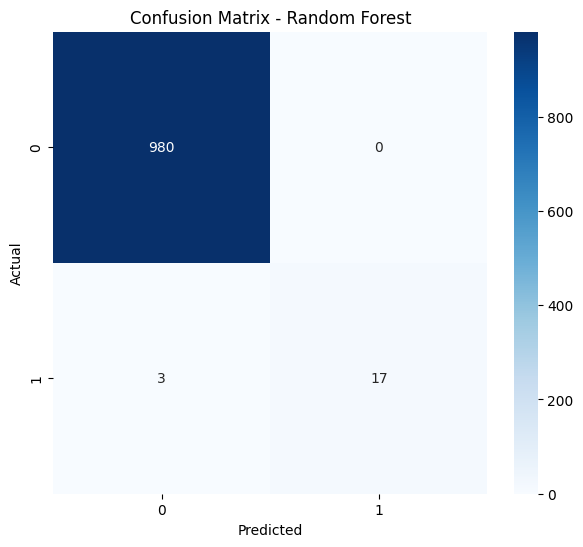


📄 CLASSIFICATION REPORT - RANDOM FOREST

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       1.00      0.85      0.92        20

    accuracy                           1.00      1000
   macro avg       1.00      0.93      0.96      1000
weighted avg       1.00      1.00      1.00      1000



In [4]:
rf_pred = rf.predict(X)

cm = confusion_matrix(y, rf_pred)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\n📄 CLASSIFICATION REPORT - RANDOM FOREST\n")
print(classification_report(y, rf_pred))

#### Gradient Boosting

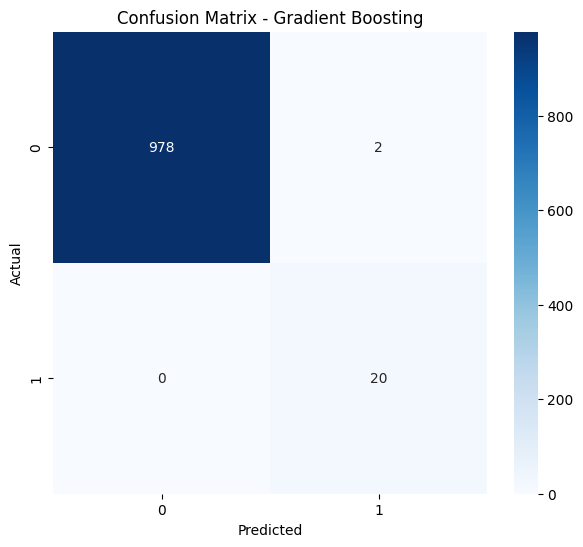


📄 CLASSIFICATION REPORT - GRADIENT BOOSTING

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       0.91      1.00      0.95        20

    accuracy                           1.00      1000
   macro avg       0.95      1.00      0.98      1000
weighted avg       1.00      1.00      1.00      1000



In [5]:
gb_pred = gb.predict(X)

cm = confusion_matrix(y, gb_pred)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Gradient Boosting")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\n📄 CLASSIFICATION REPORT - GRADIENT BOOSTING\n")
print(classification_report(y, gb_pred))

#### MLP

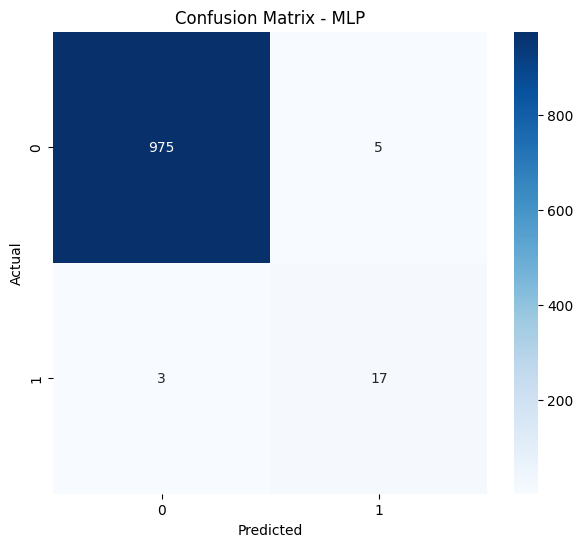


📄 CLASSIFICATION REPORT - MLP

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       980
           1       0.77      0.85      0.81        20

    accuracy                           0.99      1000
   macro avg       0.88      0.92      0.90      1000
weighted avg       0.99      0.99      0.99      1000



In [6]:
mlp_pred = mlp.predict(X)

cm = confusion_matrix(y, mlp_pred)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - MLP")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\n📄 CLASSIFICATION REPORT - MLP\n")
print(classification_report(y, mlp_pred))

#### Select Best Model

In [7]:
final_pred = rf_pred

print("Final Model Selected: Random Forest")

Final Model Selected: Random Forest


### ⚡ Risk Scoring Module

#### Generate Probability Scores

In [8]:
data['risk_prob'] = rf.predict_proba(X)[:,1]

#### Convert to 0–100 Risk Score

In [9]:
data['risk_score'] = (data['risk_prob']*100).round(2)

#### Risk Category

In [10]:
def risk_level(score):
    if score < 40:
        return "Low"
    elif score < 70:
        return "Medium"
    else:
        return "High"

data['risk_level'] = data['risk_score'].apply(risk_level)

data[['user','risk_score','risk_level']].head()

,user,risk_score,risk_level
0,AAE0190,0.0,Low
1,AAF0535,0.0,Low
2,AAF0791,0.0,Low
3,AAL0706,0.0,Low
4,AAM0658,0.0,Low


### 🚨 Alert Generation

#### High Risk Users

In [11]:
alerts = data[data['risk_level']=="High"]

alerts[['user','risk_score','risk_level']].head()

,user,risk_score,risk_level
83,ATE0869,92.5,High
141,BTW0005,76.5,High
265,DLM0051,90.0,High
380,HAD0246,72.5,High
418,HPH0075,83.0,High


### 📊 Visualization

#### Risk Distribution

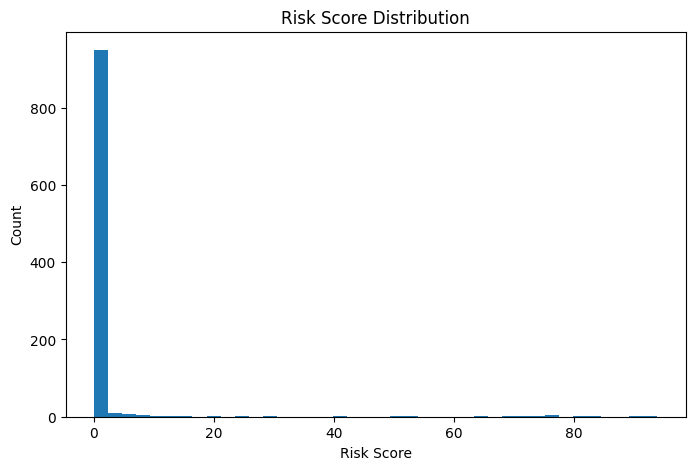

In [12]:
plt.figure(figsize=(8,5))
plt.hist(data['risk_score'], bins=40)
plt.title("Risk Score Distribution")
plt.xlabel("Risk Score")
plt.ylabel("Count")
plt.show()

#### Risk Level Count

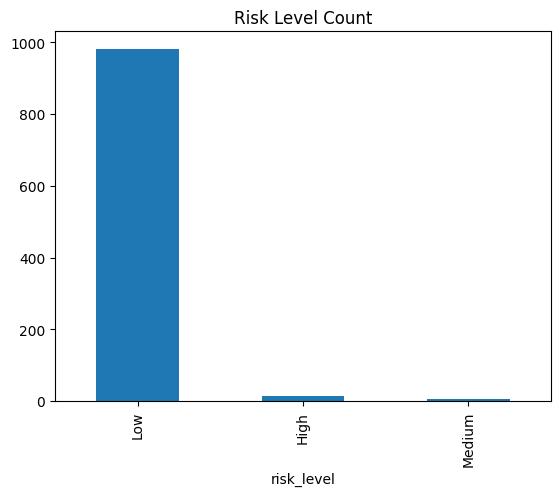

In [13]:
data['risk_level'].value_counts().plot(kind='bar')
plt.title("Risk Level Count")
plt.show()

#### Save Final Output

In [14]:
data.to_csv("../Dataset/final_risk_output.csv", index=False)
alerts.to_csv("../Dataset/high_risk_users.csv", index=False)

print("Final risk files saved ✅")

Final risk files saved ✅
